# Simple LangGraph RAG

This notebook builds a **Corrective RAG** pipeline using LangGraph with 5 nodes and conditional branching at two points.

**Graph flow:**
```
retrieve → grade_docs ──(relevant)──→ generate_answer → grade_answer ──(grounded)──→ END
               │                             ↑                 │
          (not relevant)                     │           (hallucination,
               ↓                             │            retries < 2)
          rewrite_query ────────────────────→┘
```

**Steps:**
1. Install dependencies
2. Set API keys
3. Ingest documents into a FAISS vector store
4. Define graph state
5. Initialize LLM
6. Define nodes
7. Build and compile the LangGraph
8. Visualize the graph
9. Ask questions

## 1. Install Dependencies

In [1]:
import os

if not os.path.exists('requirements.txt'):
    ! wget https://raw.githubusercontent.com/kumarsirish/FDP-AGENENTIC-AI-RAG/main/rag-langgraph-02/requirements.txt
else:
    print('requirements.txt already exists.')
%pip install -r  requirements.txt -q


requirements.txt already exists.


## 2. Detect Environment & Set API Keys

- **Google Colab** — reads from Colab *Secrets* (the 🔑 panel in the left sidebar)
- **Local** — reads from `~/FDP-AGENENTIC-AI-RAG/.env`

In [2]:
import os
from dotenv import load_dotenv

#Google Colab secrets
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN").strip()
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY").strip()

#Local Env
#load_dotenv("/home/sirkumar/FDP-AGENENTIC-AI-RAG/.env")
#HF_TOKEN=os.environ["HF_TOKEN"]
#GEMINI_API_KEY=os.environ.get["GEMINI_API_KEY"]


os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY


if not GEMINI_API_KEY or not HF_TOKEN:
    print("Warning: HF_TOKEN or GEMINI_API_KEY not set. Please set it in .env file or Colab secrets.")

## 3. Ingest Documents into FAISS Vector Store

Defines knowledge inline, splits it into chunks, embeds them using HuggingFace, and saves the vector store locally.

In [3]:
department_info = [
    # Department overview
    "The Department of Quantum Engineering (DQE) has around 140 students and 20 professors, focusing on applied quantum computing and intelligent systems.",
    "Students can choose from 5 courses ranging from core subjects to electives and hands-on project work, with strong industry exposure.",
    "DQE offers a postgraduate module 'Foundations of Quantum AI' and an undergraduate elective 'Quantum Machine Learning' using IBM Qiskit and PennyLane.",
    "All students have access to cloud quantum hardware through IBM Quantum Network and Amazon Braket as part of their coursework.",

    # Quantum AI research
    "DQE's primary research focus is Quantum AI — the intersection of quantum computing and artificial intelligence.",
    "The Quantum AI Lab investigates Quantum Neural Networks (QNNs) using parameterized quantum circuits (PQCs) and collaborates with a national quantum computing centre on 20-qubit and 50-qubit processors.",
    "A key research thread is Quantum Reinforcement Learning (QRL), where quantum agents learn policies faster than classical counterparts on specific problem classes.",
    "Project QuLearn is DQE's flagship initiative building hybrid classical-quantum models for drug discovery and materials science.",

]


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

knowledge = department_info

documents = [Document(page_content=text) for text in knowledge]

splitter = RecursiveCharacterTextSplitter(chunk_size=250, chunk_overlap=50)
docs = splitter.split_documents(documents)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L12-v2"
)

db = FAISS.from_documents(docs, embeddings)
db.save_local("vectorstore")

print(f"Vector store created successfully ({len(docs)} chunks)")

/tmp/ipykernel_7229/3791682057.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Vector store created successfully (8 chunks)


## 4. Define Graph State

In [5]:
from typing import TypedDict


class GraphState(TypedDict):
    question: str        # current question (may be rewritten)
    retrieved_docs: str  # concatenated chunk text
    doc_grade: str       # "relevant" | "not_relevant"
    answer: str          # generated answer
    answer_grade: str    # "grounded" | "hallucination"
    retries: int         # generation attempts so far
    query_rewrites: int  # number of times query has been rewritten

## 5. Initialize LLM (Model-Agnostic)

Uses LangChain's `init_chat_model` — swap providers by setting `MODEL_NAME` before running this cell:

| Provider | `MODEL_NAME` value |
|---|---|
| HuggingFace *(default)* | `huggingface:TinyLlama/TinyLlama-1.1B-Chat-v1.0` |
| Google Gemini | `google_genai:gemini-2.5-flash` |
| OpenAI | `openai:gpt-4o` |
| Anthropic | `anthropic:claude-sonnet-4-6` |
| Ollama (local) | `ollama:llama3` |

In [6]:
from langchain.chat_models import init_chat_model

MODEL_NAME = "huggingface:TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MODEL_KEY = HF_TOKEN
#MODEL_NAME = "openai:gpt-4o"
#MODEL_NAME = "anthropic:claude-sonnet-4-6"
#MODEL_NAME = "ollama:llama3"
MODEL_NAME = "google_genai:gemini-2.5-flash"
MODEL_KEY = GEMINI_API_KEY

#MODEL_NAME = "huggingface:Qwen/Qwen2.5-7B-Instruct"

llm = init_chat_model(
    MODEL_NAME,
   api_key=MODEL_KEY,
    temperature=0.1,
)

print(f"LLM ready (model: {MODEL_NAME})")

LLM ready (model: google_genai:gemini-2.5-flash)


## 6. Define Graph Nodes

Five nodes with conditional branching at two points:

| Node | Role |
|---|---|
| **retrieve** | Fetch top-k chunks from the vector store |
| **grade_docs** | LLM decides if retrieved docs are relevant to the question |
| **rewrite_query** | LLM rewrites the question when docs are not relevant |
| **generate_answer** | LLM answers using the retrieved context |
| **grade_answer** | LLM checks whether the answer is grounded in the docs |

Routing:
- After `grade_docs` → `generate_answer` if relevant, else `rewrite_query → retrieve`
- After `grade_answer` → `END` if grounded, else retry `generate_answer` (max 2 attempts)

In [7]:
from langchain_core.prompts import ChatPromptTemplate

db = FAISS.load_local(
    "vectorstore",
    embeddings,
    allow_dangerous_deserialization=True,
)


# ── Node 1: Retrieve ────────────────────────────────────────────────────────

def retrieve(state: GraphState) -> dict:
    print("\n[retrieve] Entering retrieve node.")
    docs = db.similarity_search(state["question"], k=3)
    retrieved_text = "\n".join([doc.page_content for doc in docs])
    print("[retrieve] fetched", len(docs), "chunks")
    print(f"[retrieve] Retrieved documents:\n{retrieved_text}")
    return {"retrieved_docs": retrieved_text}


# ── Node 2: Grade Docs ──────────────────────────────────────────────────────

# Define the prompt template for grade_docs
grade_docs_prompt_template = ChatPromptTemplate.from_messages([
    ("human", "Are the retrieved documents relevant to the question? Reply with exactly one word: relevant or not_relevant.\n\nQuestion: {question}\nDocuments: {retrieved_docs}")
])

def grade_docs(state: GraphState) -> dict:
    print("\n[grade_docs] Entering grade_docs node.")
    # Format the prompt using the template
    prompt = grade_docs_prompt_template.format_messages(
        question=state["question"],
        retrieved_docs=state["retrieved_docs"]
    )
    result = llm.invoke(prompt).content.strip().lower()
    # Fix: Use '==' for exact match instead of 'in' to avoid false positives
    grade = "relevant" if result == "relevant" else "not_relevant"
    print(f"[grade_docs] LLM graded documents as: {result}. Decision: {'Relevant' if grade == 'relevant' else 'Not Relevant'}")
    return {"doc_grade": grade}


def route_after_grade_docs(state: GraphState) -> str:
    if state["doc_grade"] == "relevant":
        return "generate_answer"
    # If docs are not relevant and query has not been rewritten yet, rewrite query
    elif state["query_rewrites"] < 1:
        print("\n[route_after_grade_docs] Documents not relevant, rewriting query.")
        return "rewrite_query"
    # If docs are not relevant and query has already been rewritten, try generating answer
    else:
        print("\n[route_after_grade_docs] Documents not relevant after rewrite, proceeding to generate answer.")
        return "generate_answer"


# ── Node 3: Rewrite Query ───────────────────────────────────────────────────

def rewrite_query(state: GraphState) -> dict:
    print("\n[rewrite_query] Entering rewrite_query node.")
    prompt = f"""Rewrite the question to improve retrieval. Return only the rewritten question.

Original question: {state["question"]}"""
    rewritten = llm.invoke(prompt).content.strip()
    print(f"[rewrite_query] Rewritten question: {rewritten}")
    return {"question": rewritten, "query_rewrites": state["query_rewrites"] + 1}


# ── Node 4: Generate Answer ─────────────────────────────────────────────────

# Define the prompt template for generate_answer when context is relevant
generate_answer_grounded_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "Answer the question using only the context below."),
    ("human", "Context:\n{retrieved_docs}\n\nQuestion:\n{question}")
])

# Define the prompt template for generate_answer when context is not relevant
generate_answer_ungrounded_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "The provided context does not contain relevant information to answer the question. Provide a general answer to the question, clearly stating that the answer is not based on the provided context."),
    ("human", "Question:\n{question}")
])

def generate_answer(state: GraphState) -> dict:
    print("\n[generate_answer] Entering generate_answer node.")
    # Check if documents were not relevant even after a rewrite attempt
    if state["doc_grade"] == "not_relevant" and state["query_rewrites"] >= 1:
        print("[generate_answer] Documents not relevant after rewrite. Generating general answer.")
        prompt = generate_answer_ungrounded_prompt_template.format_messages(
            question=state["question"]
        )
    else:
        prompt = generate_answer_grounded_prompt_template.format_messages(
            retrieved_docs=state["retrieved_docs"],
            question=state["question"]
        )
    response = llm.invoke(prompt)
    print("[generate_answer] done")
    return {
        "answer": response.content,
        "retries": state.get("retries", 0) + 1,
    }


# ── Node 5: Grade Answer ────────────────────────────────────────────────────

def grade_answer(state: GraphState) -> dict:
    print("\n[grade_answer] Entering grade_answer node.")
    prompt = f"""Is the answer grounded in the provided context, or does it contain hallucinations?
Reply with exactly one word: grounded or hallucination.

Context: {state["retrieved_docs"]}
Answer: {state["answer"]}"""
    result = llm.invoke(prompt).content.strip().lower()
    grade = "grounded" if "grounded" in result else "hallucination"
    print(f"[grade_answer] LLM graded answer as: {result}. Decision: {'Grounded' if grade == 'grounded' else 'Not in Docs/ Could be hallucinations'}")
    return {"answer_grade": grade}


def route_after_grade_answer(state: GraphState) -> str:
    if state["answer_grade"] == "grounded" or state.get("retries", 0) >= 2:
        return "end"
    print("\n[grade_answer] Hallucination detected — retrying generation")
    return "retry"

## 7. Build and Compile the LangGraph

LangGraph compiled successfully


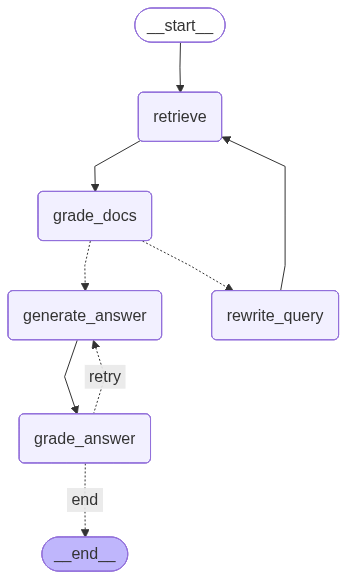

In [8]:
from langgraph.graph import StateGraph, END
from IPython.display import Image, display


graph = StateGraph(GraphState)

# Register nodes
graph.add_node("retrieve", retrieve)
graph.add_node("grade_docs", grade_docs)
graph.add_node("rewrite_query", rewrite_query)
graph.add_node("generate_answer", generate_answer)
graph.add_node("grade_answer", grade_answer)

# Entry point
graph.set_entry_point("retrieve")

# Fixed edges
graph.add_edge("retrieve", "grade_docs")
graph.add_edge("rewrite_query", "retrieve")
graph.add_edge("generate_answer", "grade_answer")

# Conditional edge 1: after grading docs
graph.add_conditional_edges(
    "grade_docs",
    route_after_grade_docs,
    {"generate_answer": "generate_answer", "rewrite_query": "rewrite_query"},
)

# Conditional edge 2: after grading answer
graph.add_conditional_edges(
    "grade_answer",
    route_after_grade_answer,
    {"end": END, "retry": "generate_answer"},
)

app = graph.compile()

print("LangGraph compiled successfully")
display(Image(app.get_graph().draw_mermaid_png()))


## 8. Ask Questions

Edit `question` below and re-run this cell to query the graph.

In [9]:
def ask(question: str):
    result = app.invoke({
        "question": question,
        "retrieved_docs": "",
        "doc_grade": "",
        "answer": "",
        "answer_grade": "",
        "retries": 0,
        "query_rewrites": 0, # Initialize query rewrite counter
    })
    print("\nAnswer:", result["answer"])

In [11]:
ask("What is DQE")


[retrieve] fetched 3 chunks
[retrieve] Retrieved documents:
DQE's primary research focus is Quantum AI — the intersection of quantum computing and artificial intelligence.
The Department of Quantum Engineering (DQE) has around 140 students and 20 professors, focusing on applied quantum computing and intelligent systems.
DQE offers a postgraduate module 'Foundations of Quantum AI' and an undergraduate elective 'Quantum Machine Learning' using IBM Qiskit and PennyLane.

[grade_docs] LLM graded documents as: relevant. Decision: Relevant

[generate_answer] done

[grade_answer] LLM graded answer as: grounded. Decision: Grounded

Answer: DQE is the Department of Quantum Engineering.


In [12]:
ask("What is quantum entanglement?")


[retrieve] fetched 3 chunks
[retrieve] Retrieved documents:
DQE's primary research focus is Quantum AI — the intersection of quantum computing and artificial intelligence.
A key research thread is Quantum Reinforcement Learning (QRL), where quantum agents learn policies faster than classical counterparts on specific problem classes.
DQE offers a postgraduate module 'Foundations of Quantum AI' and an undergraduate elective 'Quantum Machine Learning' using IBM Qiskit and PennyLane.

[grade_docs] LLM graded documents as: not_relevant. Decision: Not Relevant

[route_after_grade_docs] Documents not relevant, rewriting query.

[rewrite_query] Rewritten question: Explain quantum entanglement.

[retrieve] fetched 3 chunks
[retrieve] Retrieved documents:
DQE's primary research focus is Quantum AI — the intersection of quantum computing and artificial intelligence.
The Quantum AI Lab investigates Quantum Neural Networks (QNNs) using parameterized quantum circuits (PQCs) and collaborates with a 